In [3]:
!pip install tensorflow-datasets

import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

# load full dataset with labels
dataset, info = tfds.load('plant_village', with_info=True, as_supervised=True)

print("Classes:", info.features['label'].names)
print("Total images:", info.splits['train'].num_examples)


  DEPRECATION: Building 'promise' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'promise'. Discussion can be found at https://github.com/pypa/pip/issues/6334

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ---------------------------------------- 0.0/5.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/5.3 MB ? eta -:--:--
   --- ------------------------------------ 0.5/5.3 MB 1.3 MB/s eta 0:00:04
   ----- ---------------------------------- 0.8/5.3 MB 1.3 MB/s eta 0:00:04
   ------- -------------------------------- 1.0/5.3 MB 1.3 MB/s eta 0:00:04
   --------- ------------------------------ 1.3/5.3 MB 1.3 MB/s eta 0:00:04
   ----------- ---------------------------- 1.6/5.3 MB 1.3 MB/s eta 0:00:03
   ------------- -------------------------- 1.8/5.3 MB 1.3 MB/s eta 0:00:03
   --------------- ------------------------ 2.1/5.3 MB 1.3 MB/s eta 0:00:03
   ----------------- ---------------------- 2.4/5.3 MB 1.3 MB/s eta 0:00:03
   ------------------- -------------------- 2.6/5.3 MB 1.3 MB/s eta 0:00:0

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

ChunkedEncodingError: ('Connection broken: IncompleteRead(367469993 bytes read, 500562569 more expected)', IncompleteRead(367469993 bytes read, 500562569 more expected))

In [ ]:
# take small sample of images
train_ds = dataset['train'].shuffle(1000).take(9)

plt.figure(figsize=(9,9))
for i, (img, label) in enumerate(train_ds):
    ax = plt.subplot(3, 3, i+1)
    plt.imshow(img)
    plt.title(info.features['label'].int2str(label.numpy()))
    plt.axis("off")
plt.show()


In [4]:
import shutil
import os
shutil.rmtree(os.path.expanduser("~/.tensorflow_datasets/plant_village"), ignore_errors=True)
print("Cleared corrupted dataset cache. ✅")


Cleared corrupted dataset cache. ✅


In [5]:
import tensorflow_datasets as tfds

dataset, info = tfds.load('plant_village', with_info=True, as_supervised=True)
print("Classes:", info.features['label'].names)
print("Total images:", info.splits['train'].num_examples)


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

AssertionError: Failed to finalize writing of split "train": No examples were yielded.

In [6]:
!pip install kaggle


Defaulting to user installation because normal site-packages is not writeable

   ------------- -------------------------- 1/3 [python-slugify]
   -------------------------- ------------- 2/3 [kaggle]
   -------------------------- ------------- 2/3 [kaggle]
   -------------------------- ------------- 2/3 [kaggle]
   -------------------------- ------------- 2/3 [kaggle]
   -------------------------- ------------- 2/3 [kaggle]
   -------------------------- ------------- 2/3 [kaggle]
   -------------------------- ------------- 2/3 [kaggle]
   -------------------------- ------------- 2/3 [kaggle]
   -------------------------- ------------- 2/3 [kaggle]
   ---------------------------------------- 3/3 [kaggle]




[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
!kaggle datasets list -s plantvillage


ref                                                       title                                              size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------  -------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
abdallahalidev/plantvillage-dataset                       PlantVillage Dataset                         4371949460  2019-09-01 11:52:26.883000          88218        786  0.875            
emmarex/plantdisease                                      PlantVillage Dataset                          689512690  2018-10-30 01:16:23.440000         128126        966  0.5625           
mohitsingh1804/plantvillage                               PlantVillage                                  857351099  2021-08-20 01:08:58.493000           8697         60  0.625            
soumiknafiul/plantvillage-dataset-labeled                 PlantVi

In [8]:
!kaggle datasets download -d emmarex/plantdisease


Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown




  0%|          | 0.00/658M [00:00<?, ?B/s]
 12%|█▏        | 78.0M/658M [00:00<00:00, 810MB/s]
 24%|██▎       | 156M/658M [00:00<00:00, 690MB/s] 
 34%|███▍      | 225M/658M [00:00<00:00, 703MB/s]
 45%|████▍     | 293M/658M [00:00<00:00, 655MB/s]
 58%|█████▊    | 383M/658M [00:00<00:00, 749MB/s]
 69%|██████▉   | 456M/658M [00:00<00:00, 643MB/s]
 82%|████████▏ | 540M/658M [00:00<00:00, 709MB/s]
 93%|█████████▎| 611M/658M [00:00<00:00, 620MB/s]
100%|██████████| 658M/658M [00:01<00:00, 642MB/s]


In [9]:
import zipfile

with zipfile.ZipFile("plantdisease.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")


In [10]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "dataset/PlantVillage",
    image_size=(128, 128),
    batch_size=32,
    validation_split=0.2,
    subset="training",
    seed=123
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "dataset/PlantVillage",
    image_size=(128, 128),
    batch_size=32,
    validation_split=0.2,
    subset="validation",
    seed=123
)

class_names = train_ds.class_names
print("Classes:", class_names)


Found 41276 files belonging to 16 classes.
Using 33021 files for training.
Found 41276 files belonging to 16 classes.
Using 8255 files for validation.
Classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'PlantVillage', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


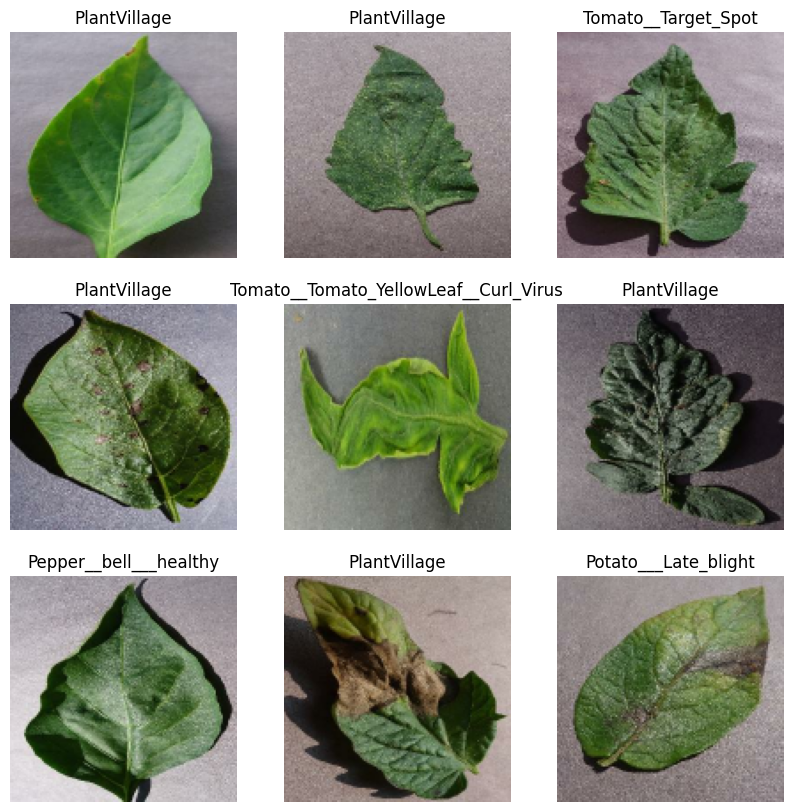

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")


In [12]:
AUTOTUNE = tf.data.AUTOTUNE

# Normalize pixel values
def normalize_img(image, label):
    return tf.cast(image, tf.float32) / 255.0, label

train_ds = train_ds.map(normalize_img, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.map(normalize_img, num_parallel_calls=AUTOTUNE)

# Improve performance with prefetching
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)


In [13]:
model = tf.keras.Sequential([
    # Step 1: First Convolution layer (detect edges)
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    tf.keras.layers.MaxPooling2D(2,2),

    # Step 2: Second layer (detect shapes)
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    # Step 3: Third layer (detect complex textures)
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    # Step 4: Flatten the 3D features into 1D
    tf.keras.layers.Flatten(),

    # Step 5: Dense layer to combine features
    tf.keras.layers.Dense(128, activation='relu'),

    # Step 6: Dropout to prevent overfitting
    tf.keras.layers.Dropout(0.3),

    # Step 7: Output layer (16 classes)
    tf.keras.layers.Dense(len(class_names), activation='softmax')
])


C:\Users\chala\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │         2,064 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,306,704 (12.61 MB)

 Trainable params: 3,306,704 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)


Epoch 1/5
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 296s 236ms/step - accuracy: 0.4875 - loss: 1.4924 - val_accuracy: 0.4796 - val_loss: 1.1474
Epoch 2/5
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 216s 209ms/step - accuracy: 0.4844 - loss: 1.1481 - val_accuracy: 0.4768 - val_loss: 1.0139
Epoch 3/5
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 192s 186ms/step - accuracy: 0.4886 - loss: 1.0384 - val_accuracy: 0.4694 - val_loss: 0.9841
Epoch 4/5
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 190s 184ms/step - accuracy: 0.4899 - loss: 0.9822 - val_accuracy: 0.4768 - val_loss: 1.0045
Epoch 5/5
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 192s 186ms/step - accuracy: 0.4964 - loss: 0.9380 - val_accuracy: 0.4590 - val_loss: 0.9516


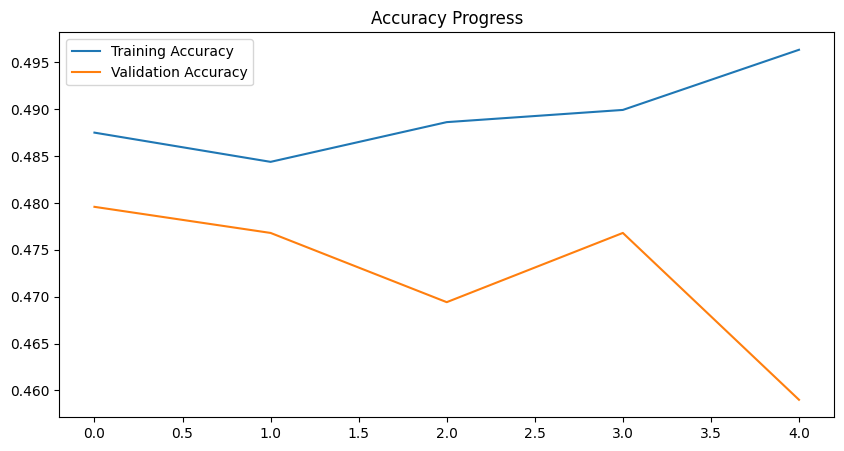

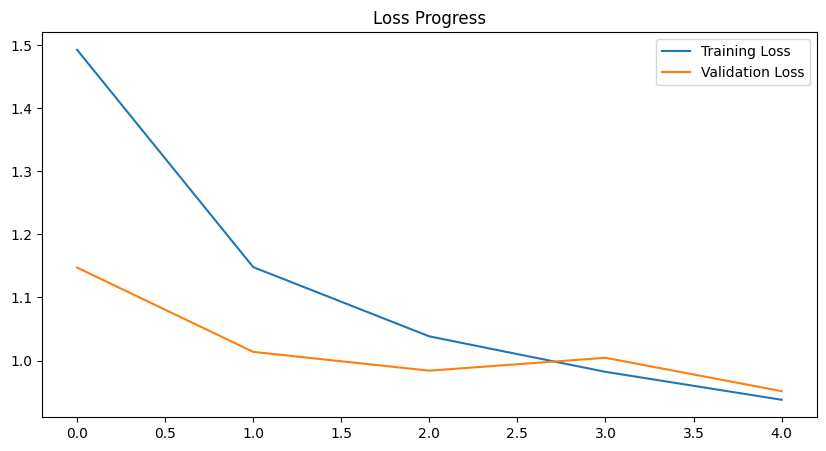

In [16]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy Progress')
plt.show()

# Plot loss
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss Progress')
plt.show()

In [17]:
from tensorflow.keras import layers, models

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),      # Flip the image horizontally
    layers.RandomRotation(0.2),           # Rotate the image a bit
    layers.RandomZoom(0.1),               # Slight zoom in/out
    layers.RandomContrast(0.1),           # Adjust brightness/contrast
])


In [18]:
model_aug = models.Sequential([
    data_augmentation,
    
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    
    layers.Dense(len(class_names), activation='softmax')
])


In [19]:
model_aug.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_aug.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
from tensorflow.keras import layers, models

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

model_aug = models.Sequential([
    layers.Input(shape=(128,128,3)),     # ADDING input layer since data augmentation didnt specify this by itself
    data_augmentation,
    
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(len(class_names), activation='softmax')
])

model_aug.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_aug.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │         4,112 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,521,040 (24.88 MB)

 Trainable params: 6,520,592 (24.87 MB)

 Non-trainable params: 448 (1.75 KB)

In [21]:

history_aug = model_aug.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)


Epoch 1/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 546s 526ms/step - accuracy: 0.4606 - loss: 2.0739 - val_accuracy: 0.4718 - val_loss: 3.5609
Epoch 2/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 495s 480ms/step - accuracy: 0.4864 - loss: 1.6135 - val_accuracy: 0.5062 - val_loss: 1.4858
Epoch 3/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 489s 474ms/step - accuracy: 0.4864 - loss: 1.5082 - val_accuracy: 0.4981 - val_loss: 1.2368
Epoch 4/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 540s 523ms/step - accuracy: 0.4869 - loss: 1.4402 - val_accuracy: 0.5039 - val_loss: 1.6167
Epoch 5/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 504s 488ms/step - accuracy: 0.4871 - loss: 1.3906 - val_accuracy: 0.4956 - val_loss: 1.4195
Epoch 6/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 470s 456ms/step - accuracy: 0.4878 - loss: 1.3535 - val_accuracy: 0.5013 - val_loss: 1.3234
Epoch 7/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 508s 492ms/step - accuracy: 0.4878 - loss: 1.3167 - val_accuracy: 0.4959 - val_loss: 1.4360
Epoch 8/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 530s 514ms/step - ac

In [22]:
model_aug.save("cnn_leaf_classifier.h5")


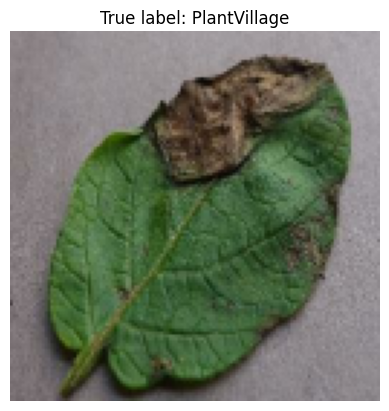

In [23]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

for images, labels in val_ds.take(1):
    sample_image = images[0].numpy()
    sample_label = labels[0].numpy()
    break

plt.imshow(sample_image)
plt.title(f"True label: {class_names[sample_label]}")
plt.axis("off")
plt.show()


In [24]:

for layer in model_aug.layers:
    print(layer.name)


sequential_3
conv2d_6
batch_normalization_3
max_pooling2d_6
conv2d_7
batch_normalization_4
max_pooling2d_7
conv2d_8
batch_normalization_5
max_pooling2d_8
flatten_2
dense_4
dropout_2
dense_5
